## Topic 1 — Introduction & Intuition

We'll continue **only within this notebook**, one topic at a time. I won't move to **Distance & Linkage Methods** until you say **next**.

---

# 1. What is Hierarchical Clustering?

**Hierarchical Clustering** is an unsupervised clustering algorithm that creates a **hierarchy of clusters**.

Instead of directly producing one fixed clustering, it builds a sequence of clusterings at different levels.

For example:

```text
Individual Points
       ↓
Small Clusters
       ↓
Larger Clusters
       ↓
One Large Cluster
```

The resulting hierarchy can be visualized using a **dendrogram**.

---

# 2. Basic Intuition

Suppose we have six data points:

```text
A   B   C              D   E   F
●   ●   ●              ●   ●   ●
```

Initially, every point is its own cluster:

```text
{A} {B} {C} {D} {E} {F}
```

The algorithm finds the most similar/closest clusters and merges them.

For example:

```text
{A} {B} {C} {D} {E} {F}
            ↓
{A,B} {C} {D} {E} {F}
            ↓
{A,B} {C} {D,E} {F}
            ↓
{A,B,C} {D,E} {F}
            ↓
{A,B,C} {D,E,F}
            ↓
{A,B,C,D,E,F}
```

So the algorithm gradually builds larger and larger clusters.

---

# 3. Why "Hierarchical"?

Because clusters exist at **multiple levels**.

For example:

```text
                 All Data
                /        \
          Cluster A     Cluster B
          /     \        /     \
        A,B      C      D,E      F
```

At one level, we could have:

```text
{A,B,C} {D,E,F}
```

At another level:

```text
{A,B} {C} {D,E} {F}
```

And initially:

```text
{A} {B} {C} {D} {E} {F}
```

So instead of asking only:

> "What are the clusters?"

we can also see:

> "How did these clusters form?"

That's the main idea behind hierarchical clustering.

---

# 4. Types of Hierarchical Clustering

There are two main approaches.

## A. Agglomerative Clustering

This is **bottom-up**.

Start with individual points:

```text
A B C D E F
↓
AB C DE F
↓
ABC DEF
↓
ABCDEF
```

Mathematically, if we start with $n$ observations:

$$n\text{ observations}\rightarrow n\text{ clusters}$$

Then repeatedly merge two clusters:

$$n\rightarrow n-1\rightarrow n-2\rightarrow\cdots\rightarrow1$$

---

## B. Divisive Clustering

This is **top-down**.

Start with one large cluster:

```text
{A,B,C,D,E,F}
```

Then split it:

```text
{A,B,C} {D,E,F}
```

Then split further:

```text
{A,B} {C} {D,E} {F}
```

Eventually:

```text
{A} {B} {C} {D} {E} {F}
```

So:

**Agglomerative:**

```text
Many → One
```

**Divisive:**

```text
One → Many
```

In practical machine learning, **agglomerative hierarchical clustering** is the approach you will primarily use.

---

# 5. Agglomerative Clustering

The word **agglomerative** means combining or merging things into larger groups.

Suppose there are $n$ observations.

Initially:

$$n\text{ observations}=n\text{ clusters}$$

At each iteration, the algorithm merges two clusters.

Eventually:

$$n\text{ clusters}\rightarrow1\text{ cluster}$$

The important question becomes:

> **Which two clusters should be merged?**

That depends on how we define the **distance between clusters**.

This leads to the concept of **linkage methods**, which is the next topic.

---

# 6. Simple Example

Suppose we have four points:

```text
A ●       ● B


C ●       ● D
```

Initially:

```text
{A} {B} {C} {D}
```

Suppose A and B are closest.

Merge them:

```text
{A,B} {C} {D}
```

Suppose C and D are closest.

Merge them:

```text
{A,B} {C,D}
```

Finally, merge the two groups:

```text
{A,B,C,D}
```

The complete process is:

```text
{A} {B} {C} {D}
       ↓
{A,B} {C} {D}
       ↓
{A,B} {C,D}
       ↓
{A,B,C,D}
```

This sequence of merges is the **hierarchy**.

---

# 7. Dendrogram

The hierarchy can be represented using a **dendrogram**.

Conceptually:

```text
Distance
   |
   |             ┌──────────────┐
   |             │              │
   |       ┌─────┘              │
   |       │                    │
   |   ┌───┘        ┌───────────┘
   |   │            │
   | ┌─┘        ┌───┘
   | │          │
   +------------------------------
     A    B     C    D    E    F
```

The vertical position where clusters merge represents their dissimilarity according to the selected linkage method.

A **low merge** means the groups were relatively close.

A **high merge** means the groups were relatively different.

---

# 8. Choosing the Number of Clusters

This is one of the biggest differences from K-Means.

### K-Means

You normally provide $K$ beforehand.

For example:

$$K=3$$

The algorithm then tries to produce three clusters.

### Hierarchical Clustering

You can build the entire hierarchy first.

You can then decide where to cut the dendrogram.

For example:

```text
                    ┌───────────────┐
                    │               │
             ┌──────┘               │
             │                      │
       ┌─────┘                 ┌────┘
       │                       │
    ┌──┘──┐                 ┌──┘──┐
    A     B                 C     D
```

If you cut the hierarchy at a particular distance, you might obtain:

```text
{A,B}
{C,D}
```

Therefore, the number of clusters can be selected **after constructing the hierarchy**.

---

# 9. Why Hierarchical Clustering is Useful

Consider customer data.

You might discover:

```text
                    All Customers
                    /            \
              Low Value         High Value
              /     \           /       \
           Budget  Regular   Premium   VIP
```

This gives you more information than simply:

```text
Cluster 1
Cluster 2
Cluster 3
Cluster 4
```

You can understand how the groups relate to each other.

This is particularly useful when the dataset has a naturally hierarchical structure.

---

# 10. Hierarchical Clustering vs K-Means

| Property                   | K-Means          | Hierarchical                |
| -------------------------- | ---------------- | --------------------------- |
| Basic idea                 | Centroids        | Hierarchy                   |
| Requires $K$ initially     | Yes              | No                          |
| Produces hierarchy         | No               | Yes                         |
| Dendrogram                 | No               | Yes                         |
| Centroids                  | Yes              | No                          |
| Uses distance              | Yes              | Yes                         |
| Noise handling             | No               | No explicit noise detection |
| Large datasets             | Generally better | Generally more expensive    |
| Hierarchical relationships | No               | Yes                         |

---

# 11. Main Advantage

The biggest advantage is:

> **You get the entire hierarchy of relationships between observations.**

You don't have to decide immediately that:

$$K=3$$

You can inspect the hierarchy and choose an appropriate level afterward.

---

# 12. Main Limitation

The major practical limitation is **computational cost**.

The algorithm repeatedly compares clusters and calculates distances.

As the number of observations becomes very large, this can become expensive.

Therefore, hierarchical clustering is generally more suitable for:

* Small datasets
* Medium-sized datasets
* Problems where hierarchical relationships are useful

rather than extremely large datasets.

---

# 13. Core Idea to Remember

The entire concept can be summarized as:

$$\text{Individual Points}\rightarrow\text{Repeatedly Merge Similar Clusters}\rightarrow\text{Hierarchy}$$

Then:

$$\text{Hierarchy}\rightarrow\text{Dendrogram}\rightarrow\text{Choose Cluster Level}$$

### The most important distinction

**K-Means:**

$$\text{Choose }K\rightarrow\text{Find }K\text{ clusters}$$

**Hierarchical:**

$$\text{Build hierarchy}\rightarrow\text{Choose cluster level}$$

---

### Notebook progress

```text
02_Hierarchical_Clustering.ipynb

✓ 1. Introduction & Intuition
→ 2. Agglomerative Clustering
→ 3. Distance & Linkage Methods
→ 4. Dendrograms & Cluster Selection
→ 5. Algorithm Concept
→ 6. Scikit-learn Implementation
→ 7. Evaluation, Comparison & Limitations
```

## Topic 2 — Agglomerative Clustering

We now go deeper into **how Agglomerative Hierarchical Clustering actually works**.

---

# 1. What is Agglomerative Clustering?

Agglomerative clustering is a **bottom-up hierarchical clustering algorithm**.

It starts by treating **every data point as an individual cluster**.

Then it repeatedly merges the two closest clusters.

The process continues until all observations belong to one cluster.

$$n\text{ points}\rightarrow n\text{ clusters}\rightarrow\cdots\rightarrow2\text{ clusters}\rightarrow1\text{ cluster}$$

---

# 2. Step-by-Step Process

Suppose we have five observations:

```text id="0s2t9g"
A   B   C   D   E
```

### Step 1 — Every point is a cluster

```text id="z4xv0x"
{A} {B} {C} {D} {E}
```

There are five clusters.

---

### Step 2 — Find the two closest clusters

Suppose A and B are closest.

Merge them:

```text id="9c7eqr"
{A,B} {C} {D} {E}
```

Now there are four clusters.

---

### Step 3 — Find the next closest clusters

Suppose D and E are closest.

```text id="n8g2vn"
{A,B} {C} {D,E}
```

Now there are three clusters.

---

### Step 4 — Continue merging

Suppose C is closest to `{A,B}`.

```text id="b5exzj"
{A,B,C} {D,E}
```

Now there are two clusters.

---

### Step 5 — Final merge

Eventually:

```text id="0rj0gi"
{A,B,C,D,E}
```

Now everything belongs to one cluster.

---

# 3. The Algorithm

The basic algorithm can be written as:

```text
1. Start with every observation as its own cluster.

2. Calculate distances between clusters.

3. Find the two closest clusters.

4. Merge those two clusters.

5. Recalculate distances involving the new cluster.

6. Repeat until only one cluster remains.
```

The key question is:

> **How do we calculate the distance between two clusters containing multiple points?**

For example:

```text id="k6f2uo"
Cluster A = {A1, A2, A3}

Cluster B = {B1, B2}
```

There isn't just one distance between these clusters.

We need a rule to define their distance.

That rule is called **linkage**.

---

# 4. Why Linkage is Necessary

Suppose we have:

```text id="6apf5c"
Cluster A              Cluster B

● ●                    ●
●                      ● ●
```

There are multiple possible point-to-point distances:

$$d(A_1,B_1),d(A_1,B_2),d(A_2,B_1),d(A_2,B_2),d(A_3,B_1),d(A_3,B_2)$$

Which one should represent the distance between the two clusters?

Different linkage methods answer this differently.

The four important ones you'll study are:

1. **Single Linkage**
2. **Complete Linkage**
3. **Average Linkage**
4. **Ward Linkage**

We'll cover these in the next topic.

---

# 5. Agglomerative Clustering is Greedy

Agglomerative clustering is a **greedy algorithm**.

At each step, it makes the locally closest merge.

For example:

```text id="x7r1mh"
Clusters:

A     B     C     D

Distances:

A-B = 2
A-C = 7
A-D = 10
B-C = 5
B-D = 8
C-D = 3
```

The closest pair is:

$$d(A,B)=2$$

So the algorithm merges A and B.

It doesn't look ahead and ask:

> "Will this produce the globally best final clustering?"

Instead, it follows the hierarchical merging process based on the chosen linkage strategy.

---

# 6. What Happens After a Merge?

This is very important.

Suppose we have:

```text id="0h4l4g"
{A} {B} {C}
```

and A and B are merged:

```text id="w4a4gk"
{A,B} {C}
```

Now we need to calculate:

$$d({A,B},C)$$

But this requires a **linkage method**.

For example, under single linkage:

$$d({A,B},C)=\min(d(A,C),d(B,C))$$

Under complete linkage:

$$d({A,B},C)=\max(d(A,C),d(B,C))$$

So the choice of linkage can completely change the hierarchy.

---

# 7. Number of Merging Operations

Suppose there are $n$ observations.

Initially:

$$n\text{ clusters}$$

Each iteration reduces the number of clusters by exactly one.

Therefore, to reach one cluster:

$$n-1\text{ merges}$$

are required.

For example, with $5$ observations:

$$5\rightarrow4\rightarrow3\rightarrow2\rightarrow1$$

Therefore:

$$5-1=4$$

merges are required.

---

# 8. Important Property: Once Merged, They Stay Merged

This is a fundamental characteristic of standard agglomerative clustering.

Suppose:

```text id="8of4v6"
A and B
   ↓
{A,B}
```

Once A and B have been merged, the algorithm does **not** later separate them.

The hierarchy is therefore **nested**.

For example:

```text id="b9m7nj"
{A}
{B}
  ↓
{A,B}
  ↓
{A,B,C}
  ↓
{A,B,C,D}
```

You never get:

```text id="hmb4qa"
{A,B}
  ↓
A and B separated again
```

This is one reason the resulting structure can naturally be represented as a tree.

---

# 9. Relationship With the Dendrogram

Every merge corresponds to a node in the dendrogram.

For example:

```text id="1y8qve"
        ┌───────────────┐
        │               │
     ┌──┴──┐         ┌──┴──┐
     │     │         │     │
     A     B         C     D
```

If A and B merge first, their branch joins at a lower height.

If `{A,B}` later merges with `{C,D}`, that merge appears higher.

The complete sequence of merges creates the dendrogram.

---

# 10. Agglomerative Clustering Example

Let's use a simple one-dimensional dataset:

```python id="b1e2r8"
X = [[1],
     [2],
     [3],
     [10],
     [11],
     [12]]
```

Visually:

```text
1   2   3                    10   11   12
●   ●   ●                    ●    ●    ●
```

The natural structure appears to be:

```text id="6u5n5d"
Cluster 1 → {1, 2, 3}

Cluster 2 → {10, 11, 12}
```

Agglomerative clustering can discover this hierarchy.

---

# 11. Scikit-Learn Implementation

The main class is:

```python id="9ik8d7"
from sklearn.cluster import AgglomerativeClustering
```

Example:

```python id="bqf5bg"
import numpy as np
from sklearn.cluster import AgglomerativeClustering

X = np.array([
    [1],
    [2],
    [3],
    [10],
    [11],
    [12]
])

model = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

labels = model.fit_predict(X)

print(labels)
```

The output may look like:

```text id="2mbq2t"
[1 1 1 0 0 0]
```

The actual numbers can be reversed:

```text
[0 0 0 1 1 1]
```

and that is equally correct.

Cluster labels are **identifiers**, not meaningful numerical values.

---

# 12. Important Parameters

The main parameters you'll encounter are:

### `n_clusters`

Number of clusters you want in the final result.

```python id="x1lj74"
AgglomerativeClustering(n_clusters=2)
```

This means:

> Build the hierarchy, then return a clustering containing two groups.

---

### `linkage`

Controls how the distance between clusters is calculated.

Common values:

```python id="hjq8yq"
"ward"
"complete"
"average"
"single"
```

We'll study exactly what each means in the next topic.

---

### `metric`

Defines the distance metric.

For example:

```python id="j1j2a8"
metric="euclidean"
```

However, there is an important restriction:

> **Ward linkage requires Euclidean distance.**

We'll understand why when we study Ward linkage.

---

# 13. A Very Important Point About `n_clusters`

Even though hierarchical clustering **doesn't need $K$ to construct the hierarchy**, the sklearn implementation commonly asks you to specify `n_clusters`.

Why?

Because sklearn can construct the hierarchical merging structure and then return the labels corresponding to the requested number of clusters.

Conceptually:

```text id="fby6w7"
Data
 ↓
Build hierarchy
 ↓
Dendrogram structure
 ↓
Cut hierarchy
 ↓
n_clusters = 2
 ↓
Return labels
```

So:

> **The algorithm conceptually builds the hierarchy first; `n_clusters` determines where we want to cut it for the returned clustering.**

---

# 14. Agglomerative Clustering vs K-Means

Consider:

```text id="2p2i4a"
K-Means:

Data
 ↓
Choose K
 ↓
Initialize centroids
 ↓
Assign points
 ↓
Update centroids
 ↓
Repeat
```

Agglomerative:

```text id="72o7p3"
Data
 ↓
Each point = cluster
 ↓
Find closest clusters
 ↓
Merge
 ↓
Find closest clusters
 ↓
Merge
 ↓
Continue
 ↓
Hierarchy
```

So their fundamental mechanisms are very different.

---

# 15. Key Takeaways

Remember these:

* **Agglomerative = bottom-up clustering**
* Every observation starts as its own cluster.
* Two clusters are repeatedly merged.
* The process continues until one cluster remains.
* There are exactly $n-1$ merges for $n$ observations.
* Once clusters merge, they are not split again.
* The complete merging process forms a **hierarchy**.
* The hierarchy can be represented using a **dendrogram**.
* **Linkage** determines how cluster-to-cluster distance is calculated.
* `n_clusters` determines the final clustering returned by sklearn.

### Notebook progress

```text
02_Hierarchical_Clustering.ipynb

✓ 1. Introduction & Intuition
✓ 2. Agglomerative Clustering
→ 3. Distance & Linkage Methods
→ 4. Dendrograms & Cluster Selection
→ 5. Algorithm Concept
→ 6. Scikit-learn Implementation
→ 7. Evaluation, Comparison & Limitations
```

# Notebook: `02_Hierarchical_Clustering.ipynb`

## Topic 3 — Distance & Linkage Methods

This is one of the **most important sections** of hierarchical clustering because the linkage method determines **which clusters get merged**.

---

# 1. Why Do We Need Linkage?

For individual points, calculating distance is straightforward.

For two points:

$$d(\boldsymbol{x}_i,\boldsymbol{x}_j)$$

But after some merging, we have clusters containing multiple points.

For example:

```text
Cluster A       Cluster B

● A₁            ● B₁
● A₂            ● B₂
● A₃
```

Now we need to determine:

> How far is Cluster A from Cluster B?

There are multiple valid definitions.

These definitions are called **linkage methods**.

The main ones are:

1. **Single Linkage**
2. **Complete Linkage**
3. **Average Linkage**
4. **Ward Linkage**

---

# 2. Single Linkage

Single linkage defines the distance between two clusters as the **minimum distance between any pair of points** from the two clusters.

Suppose:

$$A={\boldsymbol{x}_1,\boldsymbol{x}_2}$$

and:

$$B={\boldsymbol{x}_3,\boldsymbol{x}_4}$$

Then:

$$D_{\text{single}}(A,B)=\min_{\boldsymbol{x}_i\in A,\boldsymbol{x}_j\in B}d(\boldsymbol{x}_i,\boldsymbol{x}_j)$$

In simple terms:

> Find the closest pair of points between the two clusters.

---

## Example

```text
Cluster A              Cluster B

● ●                    ● ●
 ●                  ●
```

Suppose the closest points are:

```text
● ●    ● ●
     ↑
  closest pair
```

Single linkage uses **only that closest pair** to determine the cluster distance.

---

## Advantage

Single linkage can detect **elongated or irregularly shaped clusters**.

For example:

```text
● ●
  ● ●
    ● ●
      ● ●
        ● ●
```

It can connect points based on nearby neighbors.

---

## Limitation: Chaining Effect

This is the major weakness.

Imagine:

```text
● ● ● ● ● ● ● ●
                  ● ● ●
```

If consecutive points are close enough, single linkage can gradually connect everything.

This is called the **chaining effect**.

You might have two dense groups that get incorrectly merged because of a thin chain of points between them.

---

# 3. Complete Linkage

Complete linkage takes the **maximum distance** between points from the two clusters.

$$D_{\text{complete}}(A,B)=\max_{\boldsymbol{x}_i\in A,\boldsymbol{x}_j\in B}d(\boldsymbol{x}_i,\boldsymbol{x}_j)$$

In simple terms:

> Find the farthest pair of points between the two clusters.

---

## Example

```text
Cluster A              Cluster B

● ●                    ● ●
●                      ●
```

Instead of looking at the closest pair, complete linkage looks at the **worst-case distance**.

```text
● ●                    ● ●
↑                        ↑
└──── farthest pair ─────┘
```

---

## Effect

Complete linkage tends to create **compact clusters**.

It doesn't allow clusters to become too spread out because the farthest points influence the merging decision.

---

## Advantage

It reduces the chaining problem seen in single linkage.

---

## Limitation

It can struggle with naturally elongated clusters because it prefers compact groups.

---

# 4. Average Linkage

Average linkage calculates the **average distance between every pair of points across the two clusters**.

$$D_{\text{average}}(A,B)=\frac{1}{|A||B|}\sum_{\boldsymbol{x}*i\in A}\sum*{\boldsymbol{x}_j\in B}d(\boldsymbol{x}_i,\boldsymbol{x}_j)$$

So instead of using:

* minimum distance → single linkage
* maximum distance → complete linkage

we use:

> **Average of all pairwise distances.**

---

## Example

Suppose we have:

```text
A = {A₁, A₂}

B = {B₁, B₂}
```

There are four cross-cluster distances:

$$d(A_1,B_1),d(A_1,B_2),d(A_2,B_1),d(A_2,B_2)$$

Average linkage calculates their average.

---

## Effect

Average linkage is generally a compromise between:

**Single linkage**

and

**Complete linkage**

It is less affected by the chaining problem than single linkage and less aggressively compact than complete linkage.

---

# 5. Ward Linkage

Ward linkage is different from the previous three.

Instead of directly asking:

> "What is the distance between these two clusters?"

Ward asks:

> **"If I merge these two clusters, how much will the within-cluster variance increase?"**

The algorithm prefers the merge that produces the **smallest increase in within-cluster sum of squares**.

Conceptually:

$$\text{Choose merge that minimizes increase in within-cluster variance}$$

---

# 6. Understanding Ward's Idea

Suppose we have:

```text
Cluster A

● ●
● ●


Cluster B

          ● ●
          ● ●
```

Merging them creates:

```text
● ●          ● ●
● ●          ● ●
```

The resulting cluster becomes more spread out.

Ward measures how much the cluster's internal variation increases.

It chooses the merge that causes the **smallest increase**.

---

# 7. Ward Objective

For a cluster $C$, its within-cluster sum of squares can be expressed as:

$$W(C)=\sum_{\boldsymbol{x}_i\in C}|\boldsymbol{x}_i-\boldsymbol{\mu}_C|^2$$

where $\boldsymbol{\mu}_C$ is the cluster mean.

When considering merging clusters $A$ and $B$, Ward evaluates the increase:

$$\Delta W=W(A\cup B)-W(A)-W(B)$$

The pair with the smallest $\Delta W$ is preferred.

---

# 8. Why Ward Produces Compact Clusters

Because Ward tries to minimize the increase in within-cluster variation, it tends to create:

* compact clusters
* relatively spherical clusters
* clusters with similar variance

This makes Ward conceptually similar to the objective optimized by K-Means.

But the algorithms are still fundamentally different.

---

# 9. Important Restriction of Ward

Ward linkage traditionally uses **Euclidean distance**.

In scikit-learn, when using:

```python
linkage="ward"
```

the distance metric must be Euclidean.

So this combination is appropriate:

```python
AgglomerativeClustering(
    n_clusters=3,
    linkage="ward",
    metric="euclidean"
)
```

But you wouldn't use something like:

```python
linkage="ward",
metric="manhattan"
```

---

# 10. Comparing the Four Linkages

| Linkage  | Uses                 | Typical Effect                      |
| -------- | -------------------- | ----------------------------------- |
| Single   | Minimum distance     | Can create elongated clusters       |
| Complete | Maximum distance     | Compact clusters                    |
| Average  | Average distance     | Balanced behavior                   |
| Ward     | Increase in variance | Compact, roughly spherical clusters |

A useful mental model:

```text
Single
   ↓
"How close is the closest pair?"

Complete
   ↓
"How far is the farthest pair?"

Average
   ↓
"What is the average distance?"

Ward
   ↓
"How much does merging increase variance?"
```

---

# 11. Visual Intuition

Imagine two clusters:

```text
Cluster A              Cluster B

● ● ●                  ● ● ●
● ● ●                  ● ● ●
```

Different linkage methods see the separation differently.

### Single

Focuses on:

```text
closest point ↔ closest point
```

### Complete

Focuses on:

```text
farthest point ↔ farthest point
```

### Average

Considers:

```text
all cross-cluster distances
```

### Ward

Considers:

```text
increase in within-cluster variation
```

---

# 12. When Should You Use Which?

A practical starting point:

### Single linkage

Use when:

* clusters may have irregular shapes
* connectivity is important

But watch out for chaining.

### Complete linkage

Use when:

* compact clusters are desired
* you want to reduce chaining

### Average linkage

Use when:

* you want a middle ground
* neither extreme compactness nor connectivity is ideal

### Ward linkage

Use when:

* features are numerical
* Euclidean distance makes sense
* compact clusters are appropriate
* you want behavior somewhat similar to variance minimization

**Ward is often a strong default for numerical data.**

---

# 13. Connection to K-Means

There is an interesting connection.

K-Means minimizes within-cluster squared distances:

$$J=\sum_{k=1}^{K}\sum_{\boldsymbol{x}_i\in C_k}|\boldsymbol{x}_i-\boldsymbol{\mu}_k|^2$$

Ward also considers increases in within-cluster squared distances.

Therefore, both tend to favor **compact clusters**.

But:

**K-Means**

```text
Choose K
↓
Iteratively optimize centroids
```

**Ward hierarchical clustering**

```text
Start with individual points
↓
Repeatedly merge clusters
↓
Build hierarchy
```

So don't confuse them.

---

# 14. Very Important: Scaling

Distance-based linkage methods are affected by feature scales.

Suppose:

```text
Age:       18 → 80
Income:    20,000 → 2,00,000
```

Income can dominate Euclidean distances.

Therefore, preprocessing is usually important before hierarchical clustering.

A common approach is:

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
```

Then perform clustering on `X_scaled`.

---

# 15. Summary

The key formulas to remember are:

### Single

$$D_{\text{single}}(A,B)=\min_{\boldsymbol{x}_i\in A,\boldsymbol{x}_j\in B}d(\boldsymbol{x}_i,\boldsymbol{x}_j)$$

### Complete

$$D_{\text{complete}}(A,B)=\max_{\boldsymbol{x}_i\in A,\boldsymbol{x}_j\in B}d(\boldsymbol{x}_i,\boldsymbol{x}_j)$$

### Average

$$D_{\text{average}}(A,B)=\frac{1}{|A||B|}\sum_{\boldsymbol{x}*i\in A}\sum*{\boldsymbol{x}_j\in B}d(\boldsymbol{x}_i,\boldsymbol{x}_j)$$

### Ward

$$\Delta W=W(A\cup B)-W(A)-W(B)$$

and it chooses the merge with the smallest increase in within-cluster variation.

---

## Notebook Progress

```text
02_Hierarchical_Clustering.ipynb

✓ 1. Introduction & Intuition
✓ 2. Agglomerative Clustering
✓ 3. Distance & Linkage Methods
→ 4. Dendrograms & Cluster Selection
→ 5. Algorithm Concept
→ 6. Scikit-learn Implementation
→ 7. Evaluation, Comparison & Limitations
```

# Distance & Linkage Methods — Detailed Example

Let's use **one common dataset** for all four linkage methods so you can clearly see how the calculation and merging decision changes.

---

# 1. Our Example Dataset

Consider these 1D points:

```text
A = 1
B = 2
C = 5
D = 6
E = 10
```

Visual representation:

```text
1    2          5    6              10
A    B          C    D               E
●    ●          ●    ●               ●
```

Since this is 1D, distance is simply:

$$d(x_i,x_j)=|x_i-x_j|$$

Initially, every point is its own cluster:

```text
{A} {B} {C} {D} {E}
```

---

# 2. First Merge — Same for All Linkages

Initially, calculate pairwise distances:

| Pair | Distance |
| ---- | -------: |
| A-B  |        1 |
| A-C  |        4 |
| A-D  |        5 |
| A-E  |        9 |
| B-C  |        3 |
| B-D  |        4 |
| B-E  |        8 |
| C-D  |        1 |
| C-E  |        5 |
| D-E  |        4 |

The smallest distance is:

$$d(A,B)=1$$

and:

$$d(C,D)=1$$

There is a tie.

Suppose the algorithm chooses A and B first.

So:

```text
Before:

{A} {B} {C} {D} {E}

After:

{A,B} {C} {D} {E}
```

Now the important part begins.

We need to determine:

> How far is `{A,B}` from `{C}`?

Different linkage methods give different answers.

---

# 3. Single Linkage

## Definition

Single linkage uses the **closest pair** between two clusters.

$$D_{\text{single}}(A,B)=\min_{\boldsymbol{x}_i\in A,\boldsymbol{x}_j\in B}d(\boldsymbol{x}_i,\boldsymbol{x}_j)$$

Our clusters are:

```text
Cluster 1 = {A,B} = {1,2}

Cluster 2 = {C} = {5}
```

Calculate all cross-cluster distances:

$$d(A,C)=|1-5|=4$$

$$d(B,C)=|2-5|=3$$

Single linkage chooses the minimum:

$$D_{\text{single}}({A,B},{C})=\min(4,3)=3$$

So:

```text
{A,B} → {C}

distance = 3
```

---

## Distance to D

Cluster 1:

```text
{A,B} = {1,2}
```

D:

```text
{D} = {6}
```

Distances:

$$d(A,D)=|1-6|=5$$

$$d(B,D)=|2-6|=4$$

Therefore:

$$D_{\text{single}}({A,B},{D})=\min(5,4)=4$$

---

## Distance to E

$$d(A,E)=|1-10|=9$$

$$d(B,E)=|2-10|=8$$

Therefore:

$$D_{\text{single}}({A,B},{E})=\min(9,8)=8$$

So after `{A,B}` forms:

| Cluster pair      | Single linkage |
| ----------------- | -------------: |
| `{A,B}` and `{C}` |              3 |
| `{A,B}` and `{D}` |              4 |
| `{A,B}` and `{E}` |              8 |
| `{C}` and `{D}`   |              1 |
| `{C}` and `{E}`   |              5 |
| `{D}` and `{E}`   |              4 |

The smallest is still:

$$d(C,D)=1$$

Therefore:

```text
{A,B} {C} {D} {E}
       ↓
{A,B} {C,D} {E}
```

---

# 4. Now See the Chaining Effect

After we have:

```text
{A,B} {C,D} {E}
```

Calculate the single-linkage distance between `{A,B}` and `{C,D}`.

All cross distances:

$$d(A,C)=4$$

$$d(A,D)=5$$

$$d(B,C)=3$$

$$d(B,D)=4$$

Single linkage chooses:

$$D_{\text{single}}({A,B},{C,D})=\min(4,5,3,4)=3$$

So it merges:

```text
{A,B} + {C,D}
```

giving:

```text
{A,B,C,D} {E}
```

Then eventually E joins.

### Single linkage merging:

```text
{A} {B} {C} {D} {E}
 ↓
{A,B} {C} {D} {E}
 ↓
{A,B} {C,D} {E}
 ↓
{A,B,C,D} {E}
 ↓
{A,B,C,D,E}
```

### Main idea

Single linkage says:

> **"If even one pair of points between two clusters is close, I'll consider the clusters close."**

This is why it can create long chains.

---

# 5. Complete Linkage

Now let's repeat the same idea.

Complete linkage uses the **farthest pair** between two clusters.

$$D_{\text{complete}}(A,B)=\max_{\boldsymbol{x}_i\in A,\boldsymbol{x}_j\in B}d(\boldsymbol{x}_i,\boldsymbol{x}_j)$$

Again:

```text
Cluster 1 = {A,B} = {1,2}

Cluster 2 = {C} = {5}
```

Distances:

$$d(A,C)=4$$

$$d(B,C)=3$$

Complete linkage chooses:

$$D_{\text{complete}}({A,B},{C})=\max(4,3)=4$$

---

## Distance to D

$$d(A,D)=5$$

$$d(B,D)=4$$

Therefore:

$$D_{\text{complete}}({A,B},{D})=\max(5,4)=5$$

---

## Distance to E

$$d(A,E)=9$$

$$d(B,E)=8$$

Therefore:

$$D_{\text{complete}}({A,B},{E})=\max(9,8)=9$$

So:

| Cluster pair      | Complete linkage |
| ----------------- | ---------------: |
| `{A,B}` and `{C}` |                4 |
| `{A,B}` and `{D}` |                5 |
| `{A,B}` and `{E}` |                9 |
| `{C}` and `{D}`   |                1 |
| `{C}` and `{E}`   |                5 |
| `{D}` and `{E}`   |                4 |

Again C and D merge first:

```text
{A,B} {C,D} {E}
```

---

# 6. Complete Linkage After `{C,D}`

Now calculate distance between:

```text
{A,B}
```

and:

```text
{C,D}
```

All four distances:

$$d(A,C)=4$$

$$d(A,D)=5$$

$$d(B,C)=3$$

$$d(B,D)=4$$

Complete linkage takes the maximum:

$$D_{\text{complete}}({A,B},{C,D})=\max(4,5,3,4)=5$$

So:

```text
{A,B} + {C,D}
```

has distance:

$$5$$

---

## What about `{C,D}` and E?

Distances:

$$d(C,E)=5$$

$$d(D,E)=4$$

Therefore:

$$D_{\text{complete}}({C,D},{E})=\max(5,4)=5$$

There is a tie.

Depending on implementation/tie-breaking, either merge may happen first.

The important thing is the **calculation**.

### Complete linkage intuition

> **"I will merge two clusters only when even their farthest points are reasonably close."**

Therefore it tends to produce **compact clusters**.

---

# 7. Average Linkage

Now we calculate the **average of all cross-cluster distances**.

Formula:

$$D_{\text{average}}(A,B)=\frac{1}{|A||B|}\sum_{\boldsymbol{x}*i\in A}\sum*{\boldsymbol{x}_j\in B}d(\boldsymbol{x}_i,\boldsymbol{x}_j)$$

Again:

```text
{A,B} = {1,2}

{C} = {5}
```

Distances:

$$d(A,C)=4$$

$$d(B,C)=3$$

Average:

$$D_{\text{average}}({A,B},{C})=\frac{4+3}{2}=3.5$$

---

## Distance to D

Distances:

$$d(A,D)=5$$

$$d(B,D)=4$$

Average:

$$D_{\text{average}}({A,B},{D})=\frac{5+4}{2}=4.5$$

---

## Distance to E

Distances:

$$d(A,E)=9$$

$$d(B,E)=8$$

Average:

$$D_{\text{average}}({A,B},{E})=\frac{9+8}{2}=8.5$$

So:

| Cluster pair      | Average linkage |
| ----------------- | --------------: |
| `{A,B}` and `{C}` |             3.5 |
| `{A,B}` and `{D}` |             4.5 |
| `{A,B}` and `{E}` |             8.5 |
| `{C}` and `{D}`   |               1 |
| `{C}` and `{E}`   |               5 |
| `{D}` and `{E}`   |               4 |

Again:

```text
{C} + {D}
```

because:

$$1<3.5<4<4.5<5<8.5$$

---

# 8. Average Linkage After `{C,D}`

Now compare:

```text
{A,B}
```

with:

```text
{C,D}
```

Distances:

$$d(A,C)=4$$

$$d(A,D)=5$$

$$d(B,C)=3$$

$$d(B,D)=4$$

Average:

$$D_{\text{average}}({A,B},{C,D})=\frac{4+5+3+4}{4}=4$$

So the distance between the clusters is:

$$4$$

---

# 9. Ward Linkage

Ward is different.

It doesn't simply calculate minimum, maximum, or average distance.

It asks:

> **If I merge these two clusters, how much does the within-cluster sum of squares increase?**

For a cluster $C$:

$$W(C)=\sum_{\boldsymbol{x}_i\in C}|\boldsymbol{x}_i-\boldsymbol{\mu}_C|^2$$

Suppose we consider merging clusters $A$ and $B$.

The increase is:

$$\Delta W=W(A\cup B)-W(A)-W(B)$$

The merge with the **smallest increase** is selected.

---

# 10. Ward Example

Take:

```text
A = 1
B = 2
```

Each is currently its own cluster.

For `{A}`:

$$W({A})=0$$

For `{B}`:

$$W({B})=0$$

Merge them:

```text
{1,2}
```

Mean:

$$\mu=\frac{1+2}{2}=1.5$$

Within-cluster sum of squares:

$$W({1,2})=(1-1.5)^2+(2-1.5)^2=0.5$$

Therefore:

$$\Delta W=0.5-0-0=0.5$$

---

# 11. Compare A-B With C-D

We have:

```text
A = 1
B = 2

C = 5
D = 6
```

For C and D:

$$\mu=\frac{5+6}{2}=5.5$$

Therefore:

$$W({5,6})=(5-5.5)^2+(6-5.5)^2=0.5$$

So:

$$\Delta W=0.5$$

Both merges cause the same increase.

Again, there is a tie.

---

# 12. What Happens If We Compare `{A,B}` and `{C}`?

Now:

```text
A = 1
B = 2

C = 5
```

Current within-cluster cost:

$$W({1,2})=0.5$$

$$W({5})=0$$

Now merge them:

```text
{1,2,5}
```

Mean:

$$\mu=\frac{1+2+5}{3}=\frac{8}{3}$$

The new within-cluster sum of squares is:

$$W({1,2,5})=(1-\frac{8}{3})^2+(2-\frac{8}{3})^2+(5-\frac{8}{3})^2$$

This gives:

$$W({1,2,5})=\frac{26}{3}$$

Therefore the increase is:

$$\Delta W=\frac{26}{3}-0.5-0$$

$$\Delta W=\frac{49}{6}\approx8.17$$

That's much larger than the $0.5$ increase from merging A and B.

So Ward strongly prefers:

```text
A + B
```

rather than:

```text
{A,B} + C
```

---

# 13. Now You Can See the Difference

For the same clusters:

```text
A = {1,2}

B = {5,6}
```

different linkage methods calculate the cluster distance differently.

### Single

Distances:

$$4,5,3,4$$

Take minimum:

$$D_{\text{single}}=3$$

### Complete

Take maximum:

$$D_{\text{complete}}=5$$

### Average

Take average:

$$D_{\text{average}}=4$$

### Ward

Calculate increase in within-cluster variance.

It is **not simply a point-to-point distance**.

---

# 14. The Best Way to Remember Them

Imagine two clusters:

```text
Cluster A              Cluster B

● ●                    ● ●
●                      ●
```

### Single

Ask:

> **What's the closest connection?**

$$\min(\text{distances})$$

### Complete

Ask:

> **What's the worst-case separation?**

$$\max(\text{distances})$$

### Average

Ask:

> **What's the average separation?**

$$\text{mean}(\text{distances})$$

### Ward

Ask:

> **Which merge increases internal variance the least?**

$$\min(\Delta W)$$

---

# 15. How the Actual Merging Decision Happens

This is the most important part.

At every iteration:

```text
Step 1
↓
Calculate distance between all current clusters

Step 2
↓
Find the pair with the smallest linkage distance

Step 3
↓
Merge those two clusters

Step 4
↓
Recalculate distances involving the new cluster

Step 5
↓
Repeat
```

The **linkage method changes Step 1 and Step 2**, because it changes how cluster distance is calculated.

---

# 16. Final Comparison

| Method   | Calculation                         | What it asks                               |
| -------- | ----------------------------------- | ------------------------------------------ |
| Single   | Minimum pairwise distance           | "Are any points close?"                    |
| Complete | Maximum pairwise distance           | "Are all points reasonably close?"         |
| Average  | Mean pairwise distance              | "How close are they on average?"           |
| Ward     | Increase in within-cluster variance | "Which merge keeps clusters most compact?" |

### One very important takeaway

Suppose you have:

```text
Cluster A = {1, 2}

Cluster B = {5, 6}
```

The pairwise distances are:

$$4,5,3,4$$

Then:

$$D_{\text{single}}=3$$

$$D_{\text{complete}}=5$$

$$D_{\text{average}}=4$$

Ward is different because it evaluates the **change in within-cluster sum of squares**, not just these four distances.

That is the core difference between the linkage methods.

---

### Notebook Progress

```text id="w4g9vb"
02_Hierarchical_Clustering.ipynb

✓ 1. Introduction & Intuition
✓ 2. Agglomerative Clustering
✓ 3. Distance & Linkage Methods
→ 4. Dendrograms & Cluster Selection
→ 5. Algorithm Concept
→ 6. Scikit-learn Implementation
→ 7. Evaluation, Comparison & Limitations
```

## Topic 4 — Dendrograms & Cluster Selection

Now we'll understand **how the hierarchy created by agglomerative clustering is visualized** and, more importantly, **how we use it to decide the number of clusters**.

---

# 1. What is a Dendrogram?

A **dendrogram** is a tree-like diagram that shows the complete sequence of merges performed by hierarchical clustering.

For example:

```text
Distance
   |
  8|             ┌───────────────┐
   |             │               │
  6|        ┌────┘               │
   |        │                    │
  4|    ┌───┘             ┌──────┘
   |    │                 │
  2| ┌──┘              ┌──┘
   | │                 │
   +--------------------------------
      A    B    C    D    E    F
```

The important thing is the **height at which branches merge**.

That height represents the distance or linkage value at which the merge occurred.

---

# 2. What Does the Y-Axis Mean?

The y-axis represents the **distance/dissimilarity at which two clusters were merged**.

For example:

```text
Distance
   |
  10|              ┌───────────┐
   8|              │           │
   6|        ┌─────┘           │
   4|   ┌────┘                 │
   2| ──┘                      │
   +-----------------------------
```

If two points/clusters merge at height $2$:

> They were relatively close.

If two clusters merge at height $8$:

> They were much more dissimilar.

The exact interpretation of the y-axis depends on the linkage method.

---

# 3. What Does the X-Axis Mean?

The x-axis represents the observations or leaves of the hierarchy.

For example:

```text
A B C D E F
```

These are your original observations.

The ordering of leaves is mainly used to display the hierarchy clearly.

Don't interpret the horizontal distance between leaves as their actual feature-space distance.

The important information is the **vertical merge height**.

---

# 4. Let's Build a Dendrogram Manually

Use our previous dataset:

```text id="k2d0su"
A = 1
B = 2
C = 5
D = 6
E = 10
```

Suppose we are using a suitable linkage method.

The closest pairs are:

```text id="xqk6hq"
A-B → distance 1

C-D → distance 1
```

So the first merges occur at height:

$$1$$

We get:

```text id="j7e6bv"
{A,B}     {C,D}     {E}
```

Then perhaps `{C,D}` merges with E at a larger distance.

Finally, the two major groups merge at an even larger distance.

Conceptually:

```text id="4w5d5c"
Distance

  8 |                  ┌───────────────┐
    |                  │               │
  6 |          ┌───────┘               │
    |          │                       │
  4 |          │                 ┌─────┘
    |          │                 │
  2 |     ┌────┘            ┌────┘
    |     │                 │
  1 |   ┌─┴─┐             ┌─┴─┐
    |   A   B             C   D       E
    +--------------------------------------
```

The exact heights depend on the linkage method.

---

# 5. The Most Important Idea: Cutting the Dendrogram

Suppose your dendrogram looks like:

```text id="4r7t9j"
Distance

10 |             ┌─────────────────┐
   |             │                 │
 8 |       ┌─────┘                 │
   |       │                       │
 6 |       │                 ┌─────┘
   |       │                 │
 4 |   ┌───┘                 │
   |   │                     │
 2 | ──┴─────────────────────┴────
   |
   +--------------------------------
```

Imagine drawing a horizontal line at distance $5$:

```text id="o4c8nj"
Distance

10 |             ┌─────────────────┐
   |             │                 │
 8 |       ┌─────┘                 │
   |       │                       │
 6 |       │                 ┌─────┘
 5 |---------------------------------
   |       │                 │
 4 |   ┌───┘                 │
   |   │                     │
 2 | ──┴─────────────────────┴────
```

The horizontal line intersects **three branches**.

Therefore, we get:

$$K=3$$

clusters.

This is called **cutting the dendrogram**.

---

# 6. Why Does a Horizontal Cut Give Clusters?

Think about the merging process.

Suppose the hierarchy is:

```text
A B → AB

C D → CD

AB + CD → ABCD
```

At a low distance:

```text
{A} {B} {C} {D}
```

At a slightly higher distance:

```text
{A,B} {C,D}
```

At an even higher distance:

```text
{A,B,C,D}
```

So changing the cut height gives you different numbers of clusters.

---

# 7. Example of Different Cuts

Suppose the dendrogram has merge heights:

```text id="6s1bgt"
A-B       → 1
C-D       → 2
E-F       → 3
AB-CD     → 7
ABCD-EF   → 10
```

Then:

### Cut at height 0.5

No merges have happened.

$$K=6$$

Clusters:

```text id="z5i9u0"
{A} {B} {C} {D} {E} {F}
```

---

### Cut at height 2.5

The first two merges have happened:

```text id="1gc8kw"
{A,B}
{C,D}
{E}
{F}
```

So:

$$K=4$$

---

### Cut at height 5

Now A-B, C-D, and E-F have merged:

```text id="t3g2y5"
{A,B}
{C,D}
{E,F}
```

So:

$$K=3$$

---

### Cut at height 8

Now AB and CD have merged:

```text id="f9xj7n"
{A,B,C,D}
{E,F}
```

So:

$$K=2$$

---

### Cut at height 11

Everything has merged:

```text id="w8s6va"
{A,B,C,D,E,F}
```

So:

$$K=1$$

---

# 8. How Do We Actually Choose the Cut?

This is the practical question.

A common strategy is to look for a **large vertical gap** between consecutive merge heights.

Suppose the merge distances are:

```text id="k3t4sv"
1
2
2.5
3
3.2
9
```

Notice the large jump:

$$3.2\rightarrow9$$

This means several clusters remained separate until a very large distance was required to merge them.

That can indicate a natural separation.

So we might cut somewhere between:

$$3.2\text{ and }9$$

For example:

$$5$$

This could produce a reasonable number of clusters.

---

# 9. The "Largest Gap" Intuition

Imagine:

```text
Merge distance

1
2
2.5
3
3.2
        ↑
        │ large gap
        ↓
9
```

The smaller merges are happening relatively close together.

Then suddenly there is a large jump.

This suggests:

> The algorithm was merging points/clusters that were relatively similar, and then had to make a much larger jump to combine the remaining groups.

That is often a useful indication of the cluster boundary.

---

# 10. Dendrogram with a Real Example

Let's use a simple dataset:

```python id="ozd1i7"
X = [
    [1, 1],
    [1, 2],
    [2, 1],
    [8, 8],
    [8, 9],
    [9, 8]
]
```

Visually:

```text id="a1obks"
Y
↑
9                    ●
8                 ●  ●
7
6
5
4
3
2    ●  ●
1    ●
0
 +--------------------------→ X
```

There are clearly two dense groups.

We can create the dendrogram:

```python id="ib7o2y"
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X, method="ward")

dendrogram(Z)

plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")
plt.show()
```

You would see a structure where:

* points within the first group merge at small distances
* points within the second group merge at small distances
* the two large groups merge at a much larger distance

That large gap is what we're looking for.

---

# 11. What is `linkage()` Doing?

This:

```python id="zspg3r"
Z = linkage(X, method="ward")
```

performs the hierarchical merging process.

For example:

```python id="1b1u7t"
method="single"
```

uses single linkage.

```python id="9hsh8h"
method="complete"
```

uses complete linkage.

```python id="2uqe5r"
method="average"
```

uses average linkage.

```python id="h0y7t5"
method="ward"
```

uses Ward linkage.

So the dendrogram itself depends on the linkage method.

---

# 12. `Z` — The Linkage Matrix

One important technical concept:

```python id="f6j83p"
Z = linkage(X, method="ward")
```

`Z` contains the information about the hierarchy.

Each row represents a merge.

Conceptually:

```text id="xq0xri"
Z =
[
    [cluster_1, cluster_2, distance, number_of_points],
    [cluster_3, cluster_4, distance, number_of_points],
    ...
]
```

For example, a row might conceptually represent:

```text id="i4b8jm"
[0, 1, 1.2, 2]
```

meaning:

* cluster/point 0 merged with cluster/point 1
* at distance 1.2
* resulting cluster contains 2 observations

You don't need to memorize the exact matrix structure yet; just understand that `Z` stores the complete merging history.

---

# 13. Getting Clusters From the Dendrogram

Scipy provides:

```python id="m8qv5g"
from scipy.cluster.hierarchy import fcluster
```

For example:

```python id="5x2v4p"
labels = fcluster(
    Z,
    t=2,
    criterion="maxclust"
)
```

This asks for:

> Give me at most 2 clusters.

You can then inspect:

```python id="l4g0bj"
print(labels)
```

---

# 14. Dendrogram vs `n_clusters`

There's an important distinction.

### Dendrogram

Used mainly for **understanding the hierarchy and deciding where to cut**.

### `n_clusters`

Used in sklearn to directly request the final number of clusters.

For example:

```python id="g0k6tt"
model = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

labels = model.fit_predict(X)
```

Here you're saying:

> Build the hierarchical clustering and give me the result corresponding to 2 clusters.

---

# 15. Distance Threshold

Instead of explicitly saying:

```python id="xk6r6c"
n_clusters=2
```

you can conceptually choose a distance threshold.

For example:

```text id="m8d0gx"
Large merge gap
       ↓
-------------------  ← threshold
       ↓
Clusters below this level remain separate
```

In sklearn, this can be controlled using:

```python id="0g7zqm"
distance_threshold=5
```

When using `distance_threshold`, you generally set:

```python id="2b1o3e"
n_clusters=None
```

because you're telling the algorithm:

> Cut the hierarchy based on distance rather than a predetermined number of clusters.

---

# 16. Cluster Selection: Two Main Approaches

### Method 1 — Dendrogram

Look for a large gap in merge distances.

```text id="9kvzq0"
Small merges
↓
Small merges
↓
Small merges
↓
████ LARGE GAP ████
↓
Large merge
```

Choose a horizontal cut inside that gap.

---

### Method 2 — Validation Metrics

You can also try different numbers of clusters:

```text id="g2qz4h"
K = 2
K = 3
K = 4
K = 5
```

and calculate metrics such as:

* Silhouette Score
* Davies-Bouldin Index
* Calinski-Harabasz Index

We'll cover these later in the notebook's evaluation section.

---

# 17. Important Warning

Don't assume:

> "The largest gap always gives the correct number of clusters."

It is only a **heuristic**.

The best number of clusters should also make sense based on:

* domain knowledge
* visualization
* cluster quality
* stability
* downstream usefulness

For example, a mathematically good clustering may not be useful for a business problem.

---

# 18. Complete Mental Model

You should now be able to visualize the entire process:

```text id="x9x9bz"
Raw Data
   ↓
Every point = separate cluster
   ↓
Calculate cluster distances
   ↓
Choose linkage
   ↓
Merge closest clusters
   ↓
Repeat
   ↓
Complete hierarchy
   ↓
Dendrogram
   ↓
Look for meaningful cut
   ↓
Choose number of clusters
   ↓
Final cluster labels
```

---

# Key Takeaways

### Dendrogram

Shows **how clusters were progressively merged**.

### Height

Represents the **merge distance/dissimilarity** according to the linkage method.

### Horizontal cut

Determines the resulting clusters.

### Large gap

Can indicate a natural place to cut the dendrogram.

### `n_clusters`

Directly specifies the desired number of final clusters in sklearn.

### `distance_threshold`

Allows cluster selection based on a distance cutoff.

---

## Notebook Progress

```text id="f0f5e8"
02_Hierarchical_Clustering.ipynb

✓ 1. Introduction & Intuition
✓ 2. Agglomerative Clustering
✓ 3. Distance & Linkage Methods
✓ 4. Dendrograms & Cluster Selection
→ 5. Algorithm Concept
→ 6. Scikit-learn Implementation
→ 7. Evaluation, Comparison & Limitations
```

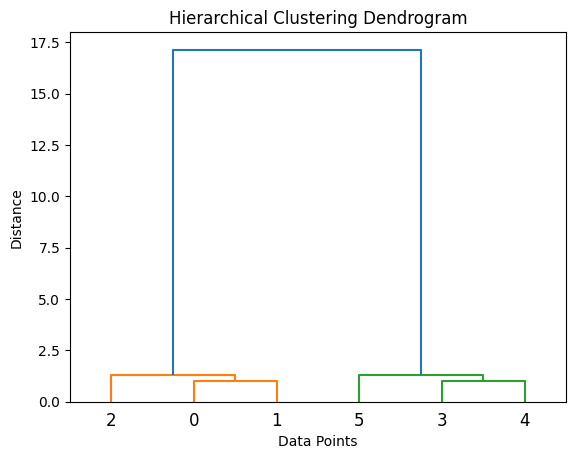

In [1]:
X = [
    [1, 1],
    [1, 2],
    [2, 1],
    [8, 8],
    [8, 9],
    [9, 8]
]

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X, method="ward")

dendrogram(Z)

plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

## Topic 5 — Algorithm Concept

Now let's put everything together and understand **exactly what the Agglomerative Hierarchical Clustering algorithm does internally**.

---

# 1. The Complete Algorithm

Suppose we have $n$ data points.

Initially:

$$C={{x_1},{x_2},\ldots,{x_n}}$$

That means:

> Every point is its own cluster.

Then repeatedly:

1. Calculate the distance between every pair of clusters.
2. Find the two closest clusters according to the selected linkage.
3. Merge them.
4. Update the cluster distances.
5. Repeat until only one cluster remains.

---

# 2. Let's Do a Complete Example

Use these 1D points:

```text id="f8g7j2"
A = 1
B = 2
C = 5
D = 6
E = 10
```

Visualize:

```text id="jv7z9j"
1    2          5    6              10
A    B          C    D               E
●    ●          ●    ●               ●
```

We'll use **single linkage** first.

---

# 3. Step 1 — Initial Clusters

Every point starts separately:

```text id="0b8zj4"
{A} {B} {C} {D} {E}
```

So there are:

$$5\text{ clusters}$$

---

# 4. Step 2 — Calculate Initial Distances

Because we're using 1D data:

$$d(x_i,x_j)=|x_i-x_j|$$

Distances:

| Pair | Distance |
| ---- | -------: |
| A-B  |        1 |
| A-C  |        4 |
| A-D  |        5 |
| A-E  |        9 |
| B-C  |        3 |
| B-D  |        4 |
| B-E  |        8 |
| C-D  |        1 |
| C-E  |        5 |
| D-E  |        4 |

Smallest:

$$1$$

There is a tie:

$$d(A,B)=1$$

and:

$$d(C,D)=1$$

Suppose we choose A and B.

---

# 5. Step 3 — Merge A and B

We create:

```text id="s4g2a7"
{A,B} {C} {D} {E}
```

The merge occurs at:

$$y=1$$

on the dendrogram.

Number of clusters:

$$5\rightarrow4$$

---

# 6. Step 4 — Update Distances

Now we need distances involving the new cluster:

```text id="b5z2o6"
{A,B}
```

and the remaining clusters:

```text id="z4l3hd"
{C}, {D}, {E}
```

Because we're using **single linkage**, take the minimum distance.

### `{A,B}` vs `{C}`

Distances:

$$d(A,C)=4$$

$$d(B,C)=3$$

Therefore:

$$D_{\text{single}}({A,B},C)=3$$

---

### `{A,B}` vs `{D}`

$$d(A,D)=5$$

$$d(B,D)=4$$

Therefore:

$$D_{\text{single}}({A,B},D)=4$$

---

### `{A,B}` vs `{E}`

$$d(A,E)=9$$

$$d(B,E)=8$$

Therefore:

$$D_{\text{single}}({A,B},E)=8$$

We still have the old distances:

$$d(C,D)=1$$

$$d(C,E)=5$$

$$d(D,E)=4$$

So the new cluster-distance table is:

| Pair        | Distance |
| ----------- | -------: |
| `{A,B}` ↔ C |        3 |
| `{A,B}` ↔ D |        4 |
| `{A,B}` ↔ E |        8 |
| C ↔ D       |        1 |
| C ↔ E       |        5 |
| D ↔ E       |        4 |

Smallest:

$$1$$

So C and D merge.

---

# 7. Step 5 — Merge C and D

Now:

```text id="zqz5jc"
{A,B} {C,D} {E}
```

Merge height:

$$y=1$$

Number of clusters:

$$4\rightarrow3$$

---

# 8. Step 6 — Calculate New Distances

Now we need:

```text id="c1f7pi"
{A,B} ↔ {C,D}
```

There are:

$$2\times2=4$$

cross-cluster distances:

$$d(A,C)=4$$

$$d(A,D)=5$$

$$d(B,C)=3$$

$$d(B,D)=4$$

Single linkage takes the minimum:

$$D_{\text{single}}({A,B},{C,D})=\min(4,5,3,4)=3$$

---

### `{C,D}` vs `{E}`

Distances:

$$d(C,E)=5$$

$$d(D,E)=4$$

Therefore:

$$D_{\text{single}}({C,D},E)=4$$

---

### `{A,B}` vs `{E}`

Already calculated:

$$D_{\text{single}}({A,B},E)=8$$

So:

| Pair              | Distance |
| ----------------- | -------: |
| `{A,B}` ↔ `{C,D}` |        3 |
| `{A,B}` ↔ E       |        8 |
| `{C,D}` ↔ E       |        4 |

Smallest:

$$3$$

Therefore merge:

```text id="q3s1bx"
{A,B} + {C,D}
```

---

# 9. Step 7 — Merge

We now have:

```text id="ihz2p7"
{A,B,C,D} {E}
```

This merge happens at:

$$y=3$$

Number of clusters:

$$3\rightarrow2$$

---

# 10. Step 8 — Final Distance

Now only two clusters remain:

```text id="h4c8q2"
{A,B,C,D}
```

and:

```text id="3xg5h9"
{E}
```

For single linkage, find the closest point in the large cluster to E.

Distances:

$$d(A,E)=9$$

$$d(B,E)=8$$

$$d(C,E)=5$$

$$d(D,E)=4$$

Therefore:

$$D_{\text{single}}({A,B,C,D},E)=\min(9,8,5,4)=4$$

So the final merge occurs at:

$$y=4$$

---

# 11. Final Hierarchy

Our entire process was:

```text id="zmyj1o"
Initial:

{A} {B} {C} {D} {E}

          ↓ distance = 1

{A,B} {C} {D} {E}

          ↓ distance = 1

{A,B} {C,D} {E}

          ↓ distance = 3

{A,B,C,D} {E}

          ↓ distance = 4

{A,B,C,D,E}
```

Therefore the dendrogram would have merge heights:

```text id="m0a5v6"
A-B       → 1
C-D       → 1
AB-CD     → 3
ABCD-E    → 4
```

---

# 12. How the Dendrogram Represents This

Conceptually:

```text id="6k0s5c"
Distance
   ↑
  4|                    ┌──────────────┐
   |                    │              │
  3|          ┌─────────┘              │
   |          │                        │
  1|     ┌────┴────┐              ┌────┘
   |     │         │              │
   |     A B       C D            E
   +------------------------------------→
```

Notice:

* A and B join at $1$
* C and D join at $1$
* AB and CD join at $3$
* ABCD and E join at $4$

That is the complete hierarchical structure.

---

# 13. Where Does Cluster Selection Happen?

The algorithm itself doesn't necessarily say:

> "These are the final clusters."

It creates the hierarchy.

Then **we choose where to cut it**.

For example, cut at:

$$2$$

Then:

```text id="x8v5eq"
{A,B}
{C,D}
{E}
```

So:

$$K=3$$

If we cut at:

$$3.5$$

then:

```text id="8gys3m"
{A,B,C,D}
{E}
```

So:

$$K=2$$

This is why the dendrogram is useful.

---

# 14. The Algorithm in Pseudocode

The actual algorithm can be summarized as:

```python id="2n0f4k"
clusters = [{x1}, {x2}, ..., {xn}]

while number_of_clusters > 1:

    calculate distance between every pair of clusters

    find pair with smallest linkage distance

    merge those two clusters

    update cluster distances
```

That's essentially what **Agglomerative Hierarchical Clustering** is doing.

---

# 15. What Changes for Complete/Average/Ward?

The algorithm stays the same:

```text id="m0d4qv"
Calculate cluster distances
        ↓
Find smallest
        ↓
Merge
        ↓
Update
        ↓
Repeat
```

Only the **distance calculation** changes.

### Single

$$D=\min(\text{all cross-cluster distances})$$

### Complete

$$D=\max(\text{all cross-cluster distances})$$

### Average

$$D=\text{average}(\text{all cross-cluster distances})$$

### Ward

$$D=\text{increase in within-cluster variance}$$

So the **linkage method determines what "closest clusters" means**.

---

# 16. Important Mental Model

You can think of hierarchical clustering as a repeated loop:

$$\text{Find closest clusters}\rightarrow\text{Merge}\rightarrow\text{Update}\rightarrow\text{Repeat}$$

And the dendrogram is simply the **visual record of every merge**.

---

## Notebook Progress

```text id="y3p9sa"
02_Hierarchical_Clustering.ipynb

✓ 1. Introduction & Intuition
✓ 2. Agglomerative Clustering
✓ 3. Distance & Linkage Methods
✓ 4. Dendrograms & Cluster Selection
✓ 5. Algorithm Concept
→ 6. Scikit-learn Implementation
→ 7. Evaluation, Comparison & Limitations
```

## Topic 6 — Scikit-learn Implementation

Now we'll implement **Agglomerative Hierarchical Clustering using Scikit-learn**.

---

# 1. Import Libraries

```python
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
```

We'll use:

* `numpy` → data
* `matplotlib` → visualization
* `AgglomerativeClustering` → clustering
* `StandardScaler` → feature scaling

---

# 2. Create Dataset

Let's create a simple dataset with three natural groups.

```python
X = np.array([
    [1, 2],
    [1, 3],
    [2, 2],
    [2, 3],

    [8, 8],
    [9, 8],
    [8, 9],
    [9, 9],

    [15, 2],
    [16, 2],
    [15, 3],
    [16, 3]
])
```

Visualize it:

```python
plt.scatter(X[:, 0], X[:, 1])

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Data")

plt.show()
```

You should see approximately three groups:

```text
        ● ●

        ● ●


                    ● ●
                    ● ●


● ●
● ●
```

---

# 3. Create the Model

```python
model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)
```

Here:

### `n_clusters=3`

We want the final result to contain 3 clusters.

### `linkage="ward"`

We're using Ward linkage.

---

# 4. Fit and Predict

```python
labels = model.fit_predict(X)

print(labels)
```

You might get:

```text
[1 1 1 1 0 0 0 0 2 2 2 2]
```

The exact numbers don't matter.

For example, sklearn could instead give:

```text
[2 2 2 2 0 0 0 0 1 1 1 1]
```

Both represent the same clustering.

Why?

Because:

```text
Cluster 0
Cluster 1
Cluster 2
```

are simply **IDs**.

There is no meaning that Cluster 2 is "better" than Cluster 1.

---

# 5. Visualize the Clusters

```python
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Clustering")

plt.show()
```

Now the points belonging to different clusters will be visually separated.

---

# 6. What Does `fit_predict()` Do?

This:

```python
labels = model.fit_predict(X)
```

is essentially doing:

```python
model.fit(X)
```

followed by:

```python
labels = model.labels_
```

So:

```text id="3u3nqk"
fit()
 ↓
Build hierarchical clustering
 ↓
Determine clusters
 ↓
predict/return labels
```

For clustering algorithms, `fit_predict()` is a convenient way to get the cluster assignments.

---

# 7. Using Different Linkages

You can change:

```python
linkage="ward"
```

to:

```python
linkage="single"
```

or:

```python
linkage="complete"
```

or:

```python
linkage="average"
```

For example:

```python
model = AgglomerativeClustering(
    n_clusters=3,
    linkage="complete"
)

labels = model.fit_predict(X)
```

The algorithm remains hierarchical, but the definition of cluster distance changes.

---

# 8. Using a Different Distance Metric

For example:

```python
model = AgglomerativeClustering(
    n_clusters=3,
    linkage="complete",
    metric="manhattan"
)
```

Here:

```text
linkage = complete
metric = manhattan
```

The pairwise point distance is Manhattan distance:

$$d(\boldsymbol{x},\boldsymbol{y})=\sum_{j=1}^{p}|x_j-y_j|$$

Then complete linkage takes the maximum of those cross-cluster distances.

---

# 9. Important Ward Restriction

For Ward:

```python
model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)
```

Ward uses **Euclidean distance**.

So don't use:

```python
linkage="ward"
metric="manhattan"
```

Use Ward with Euclidean distance.

---

# 10. Scaling the Data

In real datasets, you should usually scale numerical features when their scales differ significantly.

```python
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
```

Then:

```python
model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

labels = model.fit_predict(X_scaled)
```

Remember:

> Hierarchical clustering relies heavily on distances, so feature scale can strongly affect the result.

---

# 11. Complete Practical Example

This is the version I'd keep in your notebook:

```python
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Data
X = np.array([
    [1, 2],
    [1, 3],
    [2, 2],
    [2, 3],

    [8, 8],
    [9, 8],
    [8, 9],
    [9, 9],

    [15, 2],
    [16, 2],
    [15, 3],
    [16, 3]
])

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Model
model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

# Fit + cluster assignment
labels = model.fit_predict(X_scaled)

# Visualization
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Hierarchical Clustering")

plt.show()
```

---

# 12. Dendrogram with Scipy

Scikit-learn's `AgglomerativeClustering` is excellent for getting cluster labels, but for **actually visualizing the hierarchy**, we commonly use SciPy.

```python
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(10, 6))

dendrogram(Z)

plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.show()
```

Here:

```python
Z = linkage(X_scaled, method="ward")
```

constructs the hierarchical merging information.

Then:

```python
dendrogram(Z)
```

visualizes that hierarchy.

---

# 13. Important Difference

Use **sklearn** when you primarily want:

```text
Data
 ↓
Clustering
 ↓
Labels
```

Use **SciPy dendrogram** when you want:

```text
Data
 ↓
Hierarchical merging
 ↓
Dendrogram
 ↓
Understand cluster hierarchy
```

In your notebook, I recommend showing **both**.

---

# 14. Complete Workflow

Your practical workflow should look like:

```text
Raw Data
   ↓
EDA
   ↓
Feature Selection
   ↓
Scaling
   ↓
AgglomerativeClustering
   ↓
Cluster Labels
   ↓
Visualization
   ↓
Dendrogram
   ↓
Choose Number of Clusters
   ↓
Interpret Clusters
```

---

## Notebook Progress

```text
02_Hierarchical_Clustering.ipynb

✓ 1. Introduction & Intuition
✓ 2. Agglomerative Clustering
✓ 3. Distance & Linkage Methods
✓ 4. Dendrograms & Cluster Selection
✓ 5. Algorithm Concept
✓ 6. Scikit-learn Implementation
→ 7. Evaluation, Comparison & Limitations
```

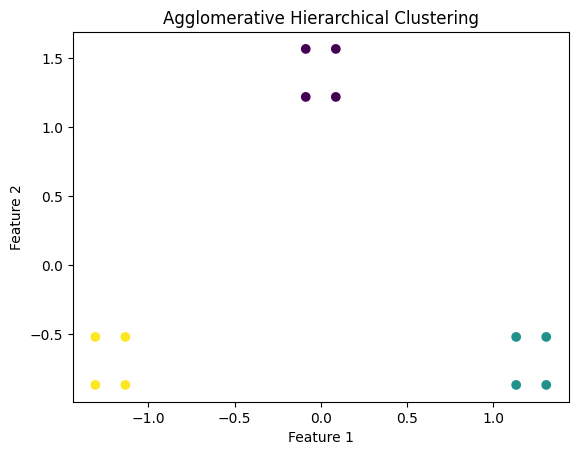

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Data
X = np.array([
    [1, 2],
    [1, 3],
    [2, 2],
    [2, 3],

    [8, 8],
    [9, 8],
    [8, 9],
    [9, 9],

    [15, 2],
    [16, 2],
    [15, 3],
    [16, 3]
])

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Model
model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

# Fit + cluster assignment
labels = model.fit_predict(X_scaled)

# Visualization
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Hierarchical Clustering")

plt.show()

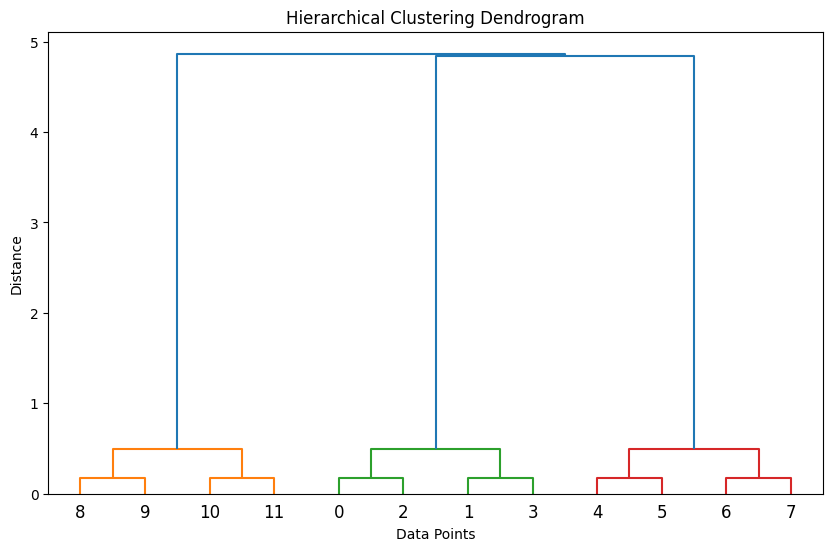

In [3]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(10, 6))

dendrogram(Z)

plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.show()

In [4]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels)

print("Silhouette Score:", score)

from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(
    X_scaled,
    labels
)

print("Davies-Bouldin Index:", db_score)

from sklearn.metrics import calinski_harabasz_score

ch_score = calinski_harabasz_score(
    X_scaled,
    labels
)

print("Calinski-Harabasz Score:", ch_score)

Silhouette Score: 0.8713516539722376
Davies-Bouldin Index: 0.16094472286258496
Calinski-Harabasz Score: 232.9797570850202


In [5]:
for k in range(2, 7):

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(k, score)

2 0.5436450087758476
3 0.8713516539722376
4 0.7528540679531748
5 0.6400336504856771
6 0.5273299402896688


# Notebook: `02_Hierarchical_Clustering.ipynb`

## Topic 7 — Evaluation, Comparison & Limitations

Now we finish the Hierarchical Clustering notebook by learning **how to judge whether the clusters are good**, how hierarchical clustering compares with other algorithms, and where it fails.

---

# 1. Why Do We Need Evaluation?

Suppose our algorithm produces:

```text
Cluster 0 → A B C D
Cluster 1 → E F G H
Cluster 2 → I J K L
```

How do we know whether this clustering is actually good?

In unsupervised learning, we usually don't have the correct labels.

So we cannot simply calculate:

```text
Accuracy = ?
```

Instead, we use **clustering evaluation metrics**.

The important ones are:

* Silhouette Score
* Davies-Bouldin Index
* Calinski-Harabasz Index
* WCSS / Inertia

---

# 2. Silhouette Score

Silhouette Score measures:

> **How well a point fits inside its own cluster compared with the nearest other cluster.**

For a point $\boldsymbol{x}_i$, define:

### $a(i)$

Average distance from the point to other points **within its own cluster**.

### $b(i)$

Lowest average distance from the point to points in another cluster.

Then:

$$s(i)=\frac{b(i)-a(i)}{\max(a(i),b(i))}$$

The overall Silhouette Score is the average:

$$S=\frac{1}{n}\sum_{i=1}^{n}s(i)$$

---

# 3. Understanding Silhouette Score

The value ranges approximately from:

$$-1\leq S\leq1$$

### Close to $1$

Excellent clustering.

The point is:

* close to its own cluster
* far from other clusters

### Around $0$

The point lies near a cluster boundary.

### Negative

The point may have been assigned to the wrong cluster.

So:

```text
1       → Very good
0.5     → Generally good
0       → Boundary
< 0     → Potentially poor assignment
```

Higher is generally better.

---

# 4. Example

Suppose a point has:

$$a(i)=2$$

and:

$$b(i)=8$$

Then:

$$s(i)=\frac{8-2}{\max(2,8)}=0.75$$

That's a good score.

The point is much closer to its own cluster than to the nearest alternative cluster.

---

# 5. Scikit-Learn Silhouette Score

```python id="p4rqmq"
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels)

print("Silhouette Score:", score)
```

For example:

```text
Silhouette Score: 0.82
```

would indicate strong separation for that dataset.

---

# 6. Davies-Bouldin Index

The **Davies-Bouldin Index** measures how similar each cluster is to its most similar neighboring cluster.

The basic idea is:

> Good clusters should be internally compact and well separated from other clusters.

Lower is better.

Unlike Silhouette:

```text
Silhouette → Higher is better
Davies-Bouldin → Lower is better
```

---

# 7. Intuition

Imagine:

```text id="1sj5c0"
Good:

● ● ●                ● ● ●
● ● ●                ● ● ●


Bad:

● ● ●  ● ● ●  ● ● ●
```

In the first case:

* clusters are compact
* clusters are separated

So the Davies-Bouldin Index tends to be lower.

---

# 8. Scikit-Learn

```python id="q9zj6v"
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(
    X_scaled,
    labels
)

print("Davies-Bouldin Index:", db_score)
```

Interpretation:

$$\text{Lower DB Index}\rightarrow\text{Better clustering}$$

---

# 9. Calinski-Harabasz Index

The **Calinski-Harabasz Index** compares:

* between-cluster dispersion
* within-cluster dispersion

Conceptually:

$$\text{CH}=\frac{\text{Between-Cluster Dispersion}}{\text{Within-Cluster Dispersion}}$$

Higher is generally better.

A good clustering should have:

```text
High between-cluster separation
+
Low within-cluster spread
```

So:

$$\text{Higher CH}\rightarrow\text{Better clustering}$$

---

# 10. Scikit-Learn

```python id="q0q4y1"
from sklearn.metrics import calinski_harabasz_score

ch_score = calinski_harabasz_score(
    X_scaled,
    labels
)

print("Calinski-Harabasz Score:", ch_score)
```

---

# 11. WCSS

You already learned WCSS.

It measures:

> How spread out points are around their cluster centers.

$$\text{WCSS}=\sum_{k=1}^{K}\sum_{\boldsymbol{x}_i\in C_k}|\boldsymbol{x}_i-\boldsymbol{\mu}_k|^2$$

Lower WCSS means more compact clusters.

But:

> **Lower WCSS alone does not mean better clustering.**

Why?

Because increasing the number of clusters generally decreases WCSS.

For example:

```text
K = 1 → WCSS = 500
K = 2 → WCSS = 250
K = 3 → WCSS = 100
K = 10 → WCSS = 0
```

Therefore, WCSS is usually useful together with something like the **Elbow Method**.

---

# 12. Comparing Different Numbers of Clusters

Suppose we don't know whether we should use:

```text
K = 2
K = 3
K = 4
K = 5
```

We can train hierarchical clustering for each value.

```python id="y1i6qf"
from sklearn.metrics import silhouette_score

for k in range(2, 7):

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(k, score)
```

You might get:

```text
2 → 0.51
3 → 0.78
4 → 0.62
5 → 0.55
6 → 0.48
```

The best Silhouette Score is:

$$0.78$$

at:

$$K=3$$

So $K=3$ would be a strong candidate.

---

# 13. But Don't Blindly Choose the Highest Score

This is important.

Suppose:

```text
K = 2 → Silhouette = 0.80
K = 3 → Silhouette = 0.76
```

You shouldn't automatically conclude:

> "K = 2 is definitely correct."

You should also consider:

* dendrogram
* domain knowledge
* cluster sizes
* visualization
* stability
* business meaning

Metrics are **evidence**, not absolute truth.

---

# 14. Hierarchical vs K-Means

Now let's compare the two.

| Property               | K-Means                    | Hierarchical         |
| ---------------------- | -------------------------- | -------------------- |
| Basic idea             | Centroids                  | Hierarchy            |
| Need $K$               | Yes                        | Not conceptually     |
| Dendrogram             | No                         | Yes                  |
| Centroids              | Yes                        | No                   |
| Noise handling         | No                         | No explicit handling |
| Large datasets         | Better                     | More expensive       |
| Arbitrary shapes       | Limited                    | Depends on linkage   |
| Hierarchical structure | No                         | Yes                  |
| Reassignment           | Points can change clusters | Merges are permanent |

---

# 15. Hierarchical vs DBSCAN

| Property            | Hierarchical               | DBSCAN                  |
| ------------------- | -------------------------- | ----------------------- |
| Main idea           | Hierarchy                  | Density                 |
| Need $K$            | Not conceptually           | No                      |
| Noise detection     | No                         | Yes                     |
| Arbitrary shapes    | Depends on linkage         | Strong                  |
| Dendrogram          | Yes                        | No                      |
| Main parameters     | Linkage, cluster selection | `eps`, `min_samples`    |
| Different densities | Can be problematic         | Can be problematic      |
| Large datasets      | Can be expensive           | Generally more scalable |

---

# 16. Major Limitations of Hierarchical Clustering

## 1. Computational Cost

Hierarchical clustering can become expensive for large datasets.

The algorithm repeatedly performs cluster-distance calculations.

Therefore:

> It is usually not the first choice for extremely large datasets.

---

## 2. Sensitive to Feature Scaling

Because clustering relies on distances, different feature scales can strongly affect the result.

For example:

```text
Age       → 20–60
Income    → 20,000–200,000
```

Income can dominate distance calculations.

Scaling is often necessary.

---

## 3. Sensitive to Linkage Choice

Different linkage methods can produce different hierarchies.

For example:

```text
Single
→ can produce chaining

Complete
→ favors compact clusters

Average
→ compromise

Ward
→ favors compact, variance-efficient clusters
```

Therefore, linkage choice matters.

---

## 4. Early Merges Cannot Be Undone

This is one of the most important limitations.

Suppose:

```text
A + B
```

are merged early.

Later, you realize they perhaps shouldn't belong together.

Standard agglomerative clustering **doesn't split them apart**.

The merge is permanent.

This is called a **greedy, irreversible merging process**.

---

## 5. Noise and Outliers

Hierarchical clustering does not have an explicit noise class like DBSCAN.

An outlier will eventually become part of some cluster because the hierarchy ultimately merges everything into one cluster.

---

# 17. When Should You Use Hierarchical Clustering?

Good situations include:

### Small/medium datasets

When computational cost isn't a major problem.

### You want hierarchical relationships

For example:

```text
Animals
├── Mammals
│   ├── Dogs
│   └── Cats
└── Birds
```

### You don't know the number of clusters beforehand

The dendrogram lets you inspect different levels.

### Exploratory analysis

You want to understand how observations relate to each other.

---

# 18. When Should You Avoid It?

Consider another algorithm when:

* dataset is extremely large
* you need very fast clustering
* you need explicit noise detection
* clusters have highly varying densities
* early incorrect merges would be problematic

---

# 19. Complete Evaluation Workflow

For your notebook, the practical workflow should be:

```text id="5g1f47"
Choose linkage
      ↓
Build hierarchy
      ↓
Generate dendrogram
      ↓
Choose candidate K
      ↓
Fit AgglomerativeClustering
      ↓
Calculate:
   ├── Silhouette
   ├── Davies-Bouldin
   └── Calinski-Harabasz
      ↓
Visualize
      ↓
Interpret clusters
      ↓
Compare different linkage methods
```

---

# 20. Final Cheat Sheet

| Metric            | Meaning                      | Better                    |
| ----------------- | ---------------------------- | ------------------------- |
| Silhouette        | Cohesion + separation        | Higher                    |
| Davies-Bouldin    | Cluster similarity           | Lower                     |
| Calinski-Harabasz | Between vs within dispersion | Higher                    |
| WCSS              | Within-cluster spread        | Lower, but depends on $K$ |

And the most important algorithm differences:

```text
K-Means
→ Centroid based

Hierarchical
→ Merge based

DBSCAN
→ Density based

GMM
→ Probability based
```

---

## Notebook Complete

```text id="h2k5u7"
02_Hierarchical_Clustering.ipynb

✓ 1. Introduction & Intuition
✓ 2. Agglomerative Clustering
✓ 3. Distance & Linkage Methods
✓ 4. Dendrograms & Cluster Selection
✓ 5. Algorithm Concept
✓ 6. Scikit-learn Implementation
✓ 7. Evaluation, Comparison & Limitations
```

Ah, yes — you want me to **actually calculate the 3 scores manually on a very small dataset**, not just give sklearn code.

Let's use this tiny dataset:

```text
A = 1
B = 2
C = 5
D = 6
```

Assume clustering:

```text
Cluster 1 = {A, B}
Cluster 2 = {C, D}
```

So:

```text
Cluster 1 → {1, 2}
Cluster 2 → {5, 6}
```

---

# 1. Silhouette Score

For each point:

$$s(i)=\frac{b(i)-a(i)}{\max(a(i),b(i))}$$

where:

* $a(i)$ = average distance to points in its own cluster
* $b(i)$ = average distance to points in the nearest other cluster

### Point A = 1

Distance to B:

$$d(A,B)=|1-2|=1$$

So:

$$a(A)=1$$

Distance to C and D:

$$d(A,C)=4$$

$$d(A,D)=5$$

Therefore:

$$b(A)=\frac{4+5}{2}=4.5$$

Silhouette:

$$s(A)=\frac{4.5-1}{\max(1,4.5)}=\frac{3.5}{4.5}=0.7778$$

---

### Point B = 2

Own cluster:

$$a(B)=|2-1|=1$$

Other cluster:

$$b(B)=\frac{|2-5|+|2-6|}{2}=\frac{3+4}{2}=3.5$$

Therefore:

$$s(B)=\frac{3.5-1}{3.5}=0.7143$$

---

### Point C = 5

Own cluster:

$$a(C)=|5-6|=1$$

Other cluster:

$$b(C)=\frac{|5-1|+|5-2|}{2}=\frac{4+3}{2}=3.5$$

Therefore:

$$s(C)=\frac{3.5-1}{3.5}=0.7143$$

---

### Point D = 6

Own cluster:

$$a(D)=|6-5|=1$$

Other cluster:

$$b(D)=\frac{|6-1|+|6-2|}{2}=\frac{5+4}{2}=4.5$$

Therefore:

$$s(D)=\frac{4.5-1}{4.5}=0.7778$$

Now average all four:

$$S=\frac{0.7778+0.7143+0.7143+0.7778}{4}=0.7461$$

### Silhouette Score

$$\boxed{S\approx0.746}$$

That's a good clustering.

---

# 2. Davies-Bouldin Index

This one is a little more involved.

For each cluster, first calculate its **average distance of points from its centroid**.

### Cluster 1

Points:

```text
1, 2
```

Centroid:

$$\mu_1=\frac{1+2}{2}=1.5$$

Average distance:

$$S_1=\frac{|1-1.5|+|2-1.5|}{2}=0.5$$

### Cluster 2

Points:

```text
5, 6
```

Centroid:

$$\mu_2=\frac{5+6}{2}=5.5$$

Average distance:

$$S_2=\frac{|5-5.5|+|6-5.5|}{2}=0.5$$

Distance between the centroids:

$$M_{12}=|1.5-5.5|=4$$

Davies-Bouldin similarity:

$$R_{12}=\frac{S_1+S_2}{M_{12}}=\frac{0.5+0.5}{4}=0.25$$

Since we only have two clusters:

$$DB=0.25$$

### Davies-Bouldin Index

$$\boxed{DB=0.25}$$

**Lower is better.**

---

# 3. Calinski-Harabasz Index

The formula is:

$$CH=\frac{B_k/(k-1)}{W_k/(n-k)}$$

where:

* $B_k$ = between-cluster dispersion
* $W_k$ = within-cluster dispersion
* $k$ = number of clusters
* $n$ = number of points

Here:

$$k=2$$

and:

$$n=4$$

---

## Step 1 — Overall Mean

All points:

```text
1, 2, 5, 6
```

Overall mean:

$$\mu=\frac{1+2+5+6}{4}=3.5$$

---

## Step 2 — Within-Cluster Dispersion

Cluster 1:

$$W_1=(1-1.5)^2+(2-1.5)^2=0.5$$

Cluster 2:

$$W_2=(5-5.5)^2+(6-5.5)^2=0.5$$

Therefore:

$$W_k=0.5+0.5=1$$

---

## Step 3 — Between-Cluster Dispersion

Cluster 1 has 2 points:

$$B_1=2(1.5-3.5)^2=8$$

Cluster 2 has 2 points:

$$B_2=2(5.5-3.5)^2=8$$

Therefore:

$$B_k=8+8=16$$

---

## Step 4 — Calculate CH

$$CH=\frac{16/(2-1)}{1/(4-2)}$$

$$CH=\frac{16}{0.5}=32$$

### Calinski-Harabasz Score

$$\boxed{CH=32}$$

**Higher is better.**

---

# Final Result

For our tiny dataset:

```text
Data:
{1, 2} → Cluster 1
{5, 6} → Cluster 2
```

| Metric            |     Score | Better |
| ----------------- | --------: | ------ |
| Silhouette        | **0.746** | Higher |
| Davies-Bouldin    |  **0.25** | Lower  |
| Calinski-Harabasz |    **32** | Higher |

So now you can see **exactly how the three scores are calculated**, rather than treating sklearn's output as a black box.
